# Problem description
The state variables are        $
x = \begin{bmatrix}x\\ y\\ \phi \end{bmatrix}
$ $\quad$
$
u = \begin{bmatrix}v_x\\ \omega \end{bmatrix}
$

$$
\dot{x} = \begin{bmatrix}v_x\cos\phi \\ v_x\sin\phi \\ \omega \end{bmatrix}
$$

There's a desired point to be at $(x_r,y_r)$

We define:
- $e_x=(x-x_r)$
- $e_y=(y-y_r)$

we want to minimize:
$$
e_x^2+e_y^2+u^TQu
$$

In [1]:
# Import necessary libraries
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import FancyArrow, Circle

# Dynamics and integration

In [2]:
# Dynamics definition

x = ca.MX.sym('x') # type: ignore
y = ca.MX.sym('y') # type: ignore
phi = ca.MX.sym('phi') # type: ignore
v_x = ca.MX.sym('v_x') # type: ignore
omega = ca.MX.sym('omega') # type: ignore

state = ca.vertcat(x, y, phi)
control = ca.vertcat(v_x, omega)

ode = ca.vertcat(
    v_x * ca.cos(phi),  # x_dot
    v_x * ca.sin(phi),  # y_dot  
    omega               # phi_dot
)

# Dynamics defined
f = ca.Function('f', [state, control], [ode], ['x', 'u'], ['ode'])

f

Function(f:(x[3],u[2])->(ode[3]) MXFunction)

## Use RK4 To discretize the system dynamics

In [3]:
N = 10  # Prediction horizon (number of time steps)
T = 0.05  # Sampling time
# Integrator options
intg_options = {
    'simplify': True,
    'number_of_finite_elements': 4
}

dae = {
    'x': state,      # What are states?
    'p': control,      # What are parameters (fixed during integration horizon)?
    'ode': f(state, control)   # Expression for the right-hand side
}
# integrator(str name, str solver, Function dae, float t0, [float] tout, dict opts) -> Function
intg = ca.integrator('intg', 'rk', dae, 0, N*T, intg_options)
x_next = intg(x0=state, p=control)['xf']

# Big F, the discretized function
F = ca.Function('F', [state, control], [x_next], ['x', 'u'], ['x_next'])
F

Function(F:(x[3],u[2])->(x_next[3]) MXFunction)

In [4]:
sim = F.mapaccum(N)
sim

Function(F_acc10:(x[3],u[2x10])->(x_next[3x10]) MXFunction)

In [5]:
# # Symbolic u

# U = ca.MX.sym('U', 2, N) # type: ignore
# U

# Solve for problem

In [6]:
x_ref, y_ref = 10, 10
x_obs, y_obs = 5, 5
r_obs = 2

In [7]:
opti = ca.Opti()

x = opti.variable(3, N+1) # type: ignore
u = opti.variable(2, N) # type: ignore
p = opti.parameter(3, 1) # type: ignore

# opti.minimize(ca.sumsqr(x-ca.vertcat(x_ref, y_ref, 0)))
opti.minimize(ca.sumsqr(x[0,:]-x_ref) + ca.sumsqr(x[1,:]-y_ref) + ca.sumsqr(u))

for k in range(N):
    opti.subject_to(x[:, k+1] == F(x[:, k], u[:, k]))



opti.subject_to(x[:,0] == p)

# Set speed limit
opti.subject_to(u[0, :] <= 1)
opti.subject_to(u[0, :] >= 0)
opti.subject_to(u[1, :] <= 1)
opti.subject_to(u[1, :] >= -1)
# Obstacle Limit
for k in range(N+1):
    opti.subject_to(ca.sumsqr(x[0:2, k]-ca.vertcat(x_obs, y_obs)) >= r_obs**2) 
# Set initial condition
opti.subject_to(x[:,0] == p)


# opti.solver('worhp')

# opti.solver('sqpmethod')
opti.solver('ipopt')
opti.set_value(p, ca.vertcat(0, 0, 0))
sol = opti.solve()


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      136
Number of nonzeros in inequality constraint Jacobian.:       62
Number of nonzeros in Lagrangian Hessian.............:       82

Total number of variables............................:       53
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       36
Total number of inequality c

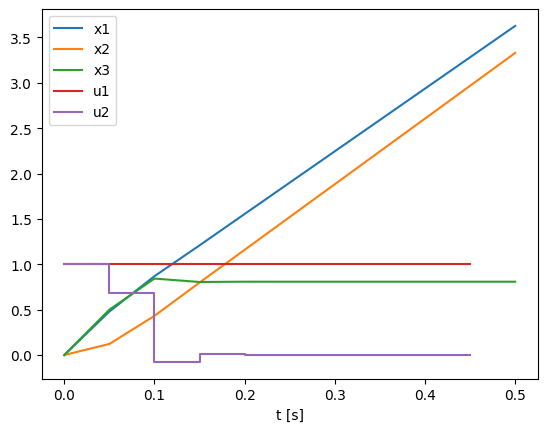

In [8]:
# Extract values from CasADi solution
x_vals = sol.value(x)  # Shape: (3, N) for 3 states
u_vals = sol.value(u)  # Shape: (2, N) for 2 inputs

tgrid = np.linspace(0, T*N, N+1)
plt.figure()
# Plot 3 states
plt.plot(tgrid, x_vals[0, :], label='x')
plt.plot(tgrid, x_vals[1, :], label='y') 
plt.plot(tgrid, x_vals[2, :], label='theta')

# Plot 2 inputs as steps
plt.step(tgrid[:-1], u_vals[0, :], where='post', label='u1')
plt.step(tgrid[:-1], u_vals[1, :], where='post', label='u2')

plt.xlabel('t [s]')
plt.legend(['x1', 'x2', 'x3', 'u1', 'u2'])

(np.float64(-0.49999999999999944),
 np.float64(10.5),
 np.float64(-0.49999999999999944),
 np.float64(10.5))

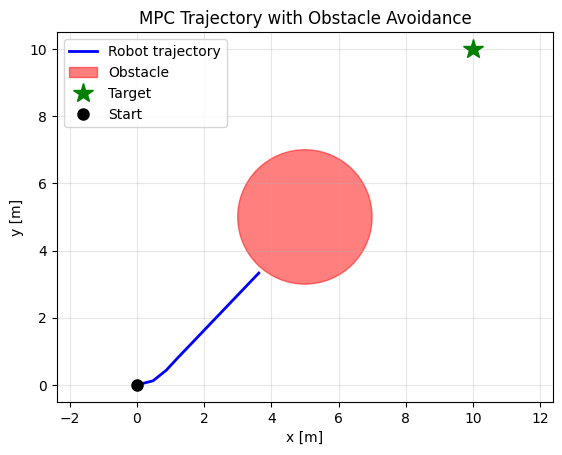

In [9]:
plt.figure()
plt.plot(x_vals[0, :], x_vals[1, :], 'b-', linewidth=2, label='Robot trajectory')

# Add obstacle visualization
obstacle_circle = Circle((x_obs, y_obs), r_obs, color='red', alpha=0.5, label='Obstacle')
plt.gca().add_patch(obstacle_circle)

# Add reference point
plt.plot(x_ref, y_ref, 'g*', markersize=15, label='Target')

# Add start point
plt.plot(x_vals[0, 0], x_vals[1, 0], 'ko', markersize=8, label='Start')

plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('MPC Trajectory with Obstacle Avoidance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

In [10]:
M = opti.to_function('M',[p],[u[:,0]],['p'],['u_opt'])
M

Function(M:(p[3])->(u_opt[2]) MXFunction)

## MPC Loop

In [11]:
x_log = []
u_log = []

x = ca.vertcat(0, 0, 0)


for i in range(100):
    u = M(x)
    x_log.append(x)
    u_log.append(u)
    x = F(x, u)

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      136
Number of nonzeros in inequality constraint Jacobian.:       62
Number of nonzeros in Lagrangian Hessian.............:       82

Total number of variables............................:       53
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       36
Total number of inequality constraints...............:       51
        inequality constraints with only lower bounds:       31
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       20

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.2000000e+03 0.00e+00 2.00e+01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

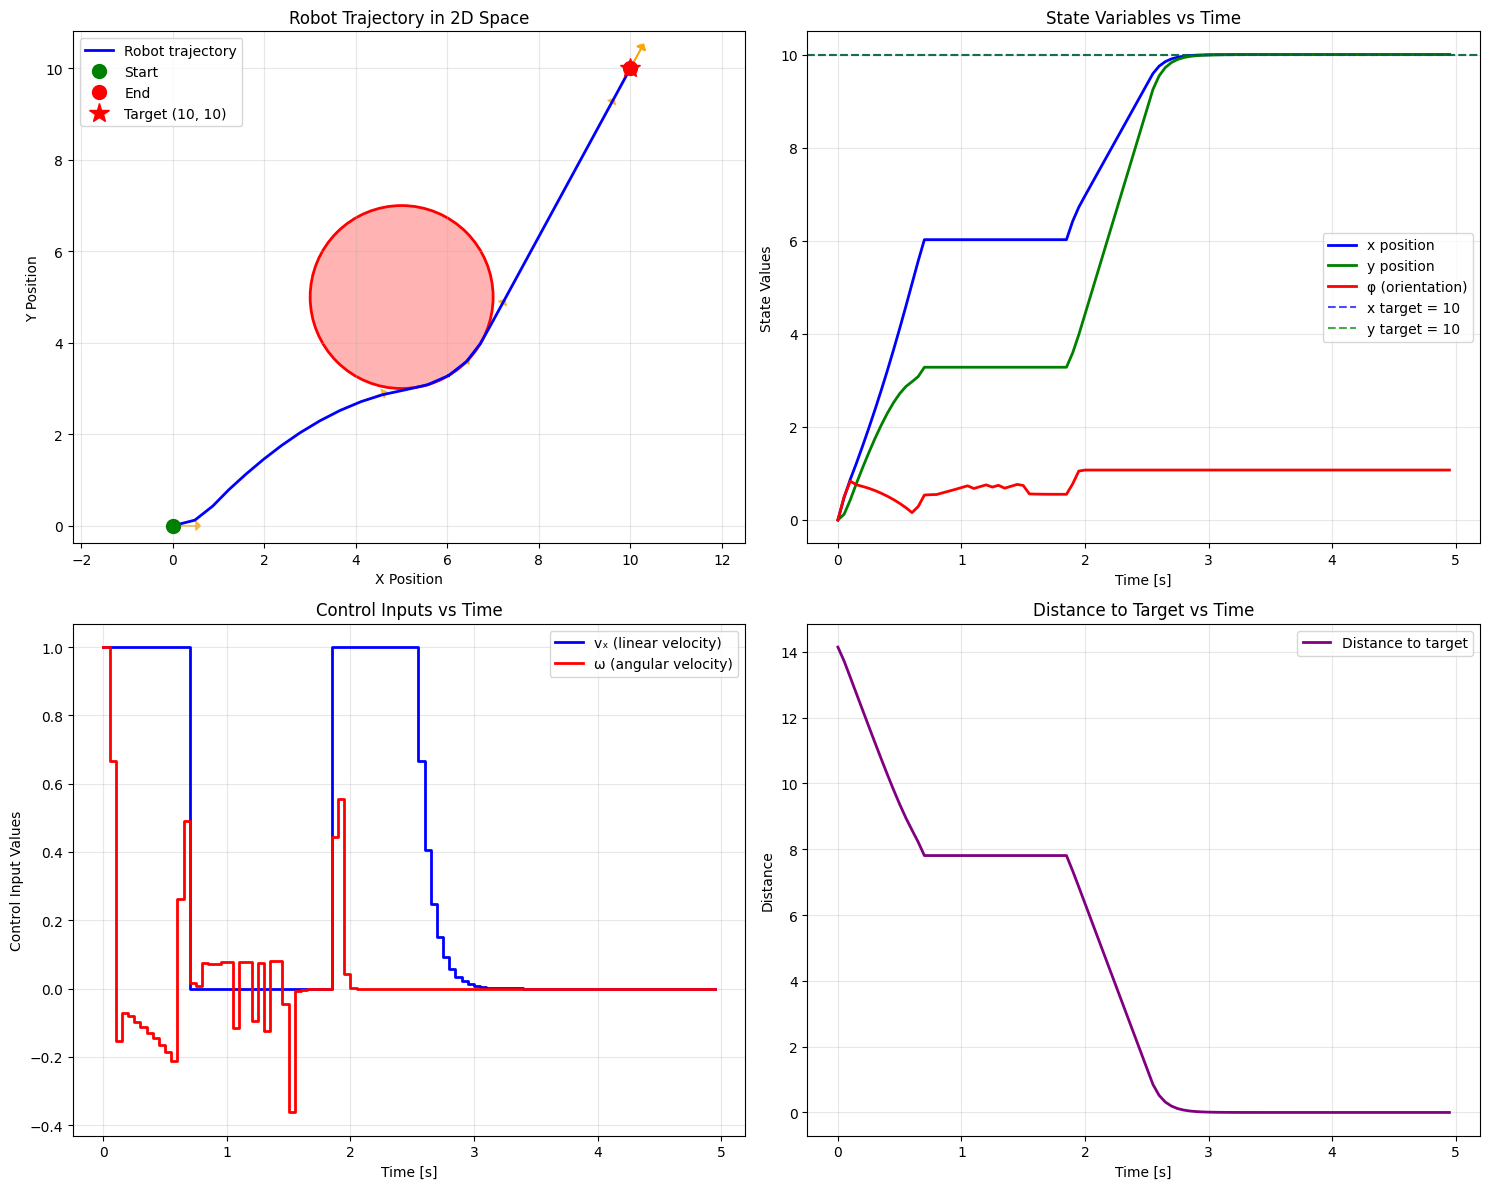

Simulation completed:
- Duration: 5.0 seconds
- Final position: (10.00, 10.00)
- Target position: (10, 10)
- Final distance to target: 0.000
- Final orientation: 1.073 rad (61.5°)


In [12]:
# Convert CasADi arrays to numpy for plotting
from matplotlib import patches


x_traj = np.array([np.array(x).flatten() for x in x_log])  # Shape: (N, 3)
u_traj = np.array([np.array(u).flatten() for u in u_log])  # Shape: (N, 2)

# Time vector
time_steps = np.arange(len(x_log)) * T

# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. Trajectory in 2D space
ax1.plot(x_traj[:, 0], x_traj[:, 1], 'b-', linewidth=2, label='Robot trajectory')
ax1.plot(x_traj[0, 0], x_traj[0, 1], 'go', markersize=10, label='Start')
ax1.plot(x_traj[-1, 0], x_traj[-1, 1], 'ro', markersize=10, label='End')
ax1.plot(x_ref, y_ref, 'r*', markersize=15, label=f'Target ({x_ref}, {y_ref})')

# Add orientation arrows at regular intervals
arrow_interval = max(1, len(x_traj) // 10)
for i in range(0, len(x_traj), arrow_interval):
    x, y, phi = x_traj[i]
    dx = 0.5 * np.cos(phi)
    dy = 0.5 * np.sin(phi)
    ax1.arrow(x, y, dx, dy, head_width=0.2, head_length=0.1, 
              fc='orange', ec='orange', alpha=0.7)
# Create a circle with center (5,5) and radius 2
circle = patches.Circle((5, 5), radius=2, fill=True,facecolor='#FFB3B3', edgecolor='red', linewidth=2)

# Add the circle to the plot
ax1.add_patch(circle)

ax1.set_xlabel('X Position')
ax1.set_ylabel('Y Position')
ax1.set_title('Robot Trajectory in 2D Space')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axis('equal')

# 2. State variables over time
ax2.plot(time_steps, x_traj[:, 0], 'b-', linewidth=2, label='x position')
ax2.plot(time_steps, x_traj[:, 1], 'g-', linewidth=2, label='y position')
ax2.plot(time_steps, x_traj[:, 2], 'r-', linewidth=2, label='φ (orientation)')
ax2.axhline(y=x_ref, color='b', linestyle='--', alpha=0.7, label=f'x target = {x_ref}')
ax2.axhline(y=y_ref, color='g', linestyle='--', alpha=0.7, label=f'y target = {y_ref}')
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('State Values')
ax2.set_title('State Variables vs Time')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. Control inputs over time
ax3.step(time_steps, u_traj[:, 0], 'b-', linewidth=2, where='post', label='vₓ (linear velocity)')
ax3.step(time_steps, u_traj[:, 1], 'r-', linewidth=2, where='post', label='ω (angular velocity)')
ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Control Input Values')
ax3.set_title('Control Inputs vs Time')
ax3.grid(True, alpha=0.3)
ax3.legend()

# 4. Distance to target over time
distances = np.sqrt((x_traj[:, 0] - x_ref)**2 + (x_traj[:, 1] - y_ref)**2)
ax4.plot(time_steps, distances, 'purple', linewidth=2, label='Distance to target')
ax4.set_xlabel('Time [s]')
ax4.set_ylabel('Distance')
ax4.set_title('Distance to Target vs Time')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

# Print some statistics
print(f"Simulation completed:")
print(f"- Duration: {time_steps[-1]:.1f} seconds")
print(f"- Final position: ({x_traj[-1, 0]:.2f}, {x_traj[-1, 1]:.2f})")
print(f"- Target position: ({x_ref}, {y_ref})")
print(f"- Final distance to target: {distances[-1]:.3f}")
print(f"- Final orientation: {x_traj[-1, 2]:.3f} rad ({np.degrees(x_traj[-1, 2]):.1f}°)")